In [4]:
import random
import introns
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

1. Nauczyc nowy model rozpoznajacy niekonwencjonalne

In [2]:
genome, genes = introns.HELP_load_default_genome_genes(if_classifier_mixed=True)

Creating genes, sequences, introns, exons and introns' class prediction


100%|██████████| 117/117 [00:00<00:00, 528.32it/s]


[CREATE] Genes, sequences, introns, exons created, introns' classes predicted
predict_all_introns checkpoint 1/4
predict_all_introns checkpoint 2/4
predict_all_introns checkpoint 3/4
predict_all_introns checkpoint 4/4


In [3]:
#introns_set = [i for (_, gene) in list(genes.items())[:50] for i in gene.introns[:50]]
introns_set = [i for (_, gene) in genes.items() for i in gene.introns]

In [5]:
random.shuffle(introns_set)
halfway = int(len(introns_set)/2)
introns_clf_set, introns_validation_set = introns_set[:halfway], introns_set[halfway:]

In [6]:
train_test_set, true_classes = [], []

for intron in introns_clf_set:
    for i in intron.variants+[intron]:
        i.ML_characteristic = introns.compute_intron_characteristics(i, whether_weighted_scores=True)
        train_test_set.append(i.ML_characteristic)
        if i.man_annotation == "intron_NK":
            true_classes.append(1)
        else:
            true_classes.append(0)
                
print(train_test_set[0])
print(true_classes[0])

[1.  0.  0.  1.  0.  2.5 2.5 1. ]
0


In [7]:
X_train, X_test, y_train, y_test = train_test_split(train_test_set, true_classes, random_state=2137, shuffle=True)

In [8]:
clf_nk = xgb.XGBClassifier(eval_metric='aucpr')
clf_nk.fit(X_train, y_train);

In [9]:
y_predicted = clf_nk.predict(X_test)
print(classification_report(y_test, y_predicted))
print(confusion_matrix(y_test, y_predicted), "\n\n")

              precision    recall  f1-score   support

           0       0.92      0.91      0.92       226
           1       0.49      0.51      0.50        37

    accuracy                           0.86       263
   macro avg       0.70      0.71      0.71       263
weighted avg       0.86      0.86      0.86       263

[[206  20]
 [ 18  19]] 




2. Polaczenie klasyfikatorow

In [10]:
for intron in introns_validation_set:
    for i in intron.variants+[intron]:
        is_k = int(bool(i.is_conventional))
        
        i.ML_characteristic = introns.compute_intron_characteristics(i, whether_weighted_scores=True).reshape(1, -1)
        is_nk = clf_nk.predict(i.ML_characteristic)[0]
        
        i.ML_class = [is_k, is_nk]

3. Wykresy, statystyki

3.1. Position finding

In [11]:
def get_position_finding_stats(introns_to_grade, grade_which="NK", grade_as="NK"):
    #@TODO
    # if not (grade_which=="NK"):
    #     raise ValueError("Not implemented yet")
    
    primary_pos, secondary_pos, all_pos, all_introns = 0, 0, 0, 0
    
    for intron in introns_to_grade:
        if intron.man_annotation!=f"intron_{grade_which}":
            continue
        all_introns += 1

        if_sec_pos = 1
        for v in intron.variants:
            if (grade_as=="NK" and v.is_ML_nonconv()) or (grade_as=="K" and v.is_ML_conv()):
                if_sec_pos = 0
                break
        secondary_pos += if_sec_pos
        
        if (grade_as=="NK" and intron.is_ML_nonconv()) or (grade_as=="K" and intron.is_ML_conv()):
            primary_pos += 1
            if if_sec_pos:
                all_pos += 1
    
    return primary_pos, secondary_pos, all_pos, all_introns

def plot_correct_positions(introns_to_grade, grade_which="NK", grade_as="NK"):
    try:
        correct_primary_pos, correct_variations, correct_full, all_introns = get_position_finding_stats(introns_to_grade, grade_which, grade_as)
    except ValueError:
        return
    bar_labels = [
f"""primary position
correctly identified
as {grade_as}""",
f"""no variant
is classified
as {grade_as}""",
f"""primary position
is the only out of
all variants to
be classified as {grade_as}""",
"# of all introns"]
    plt.figure(figsize=(10,5))
    plt.bar(bar_labels,
            [correct_primary_pos, correct_variations, correct_full, all_introns])
    for i, n in enumerate([correct_primary_pos, correct_variations, correct_full, all_introns]):
        plt.text(i-0.25, n+1, "{:.2f}% ({})".format(n/all_introns*100, n))
    plt.title(f"How many {grade_which} introns' positions are classified as {grade_as}?")
    #plt.savefig("classifying_variants.png", transparent=False, facecolor='1')
    plt.show()

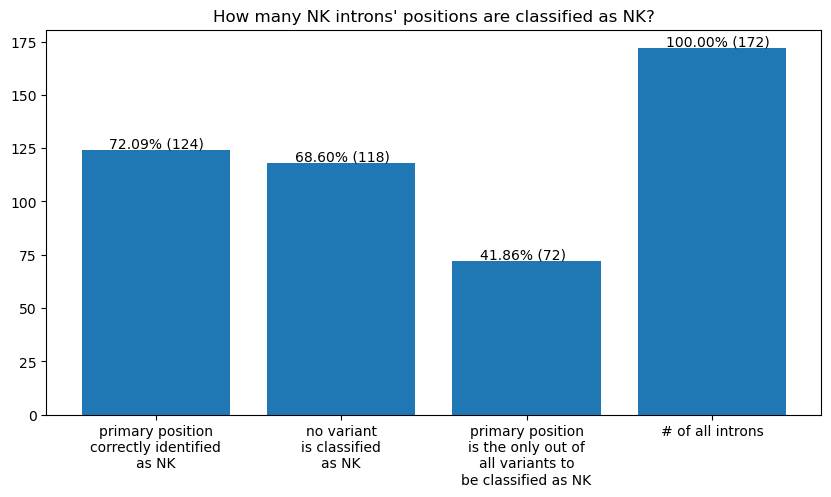

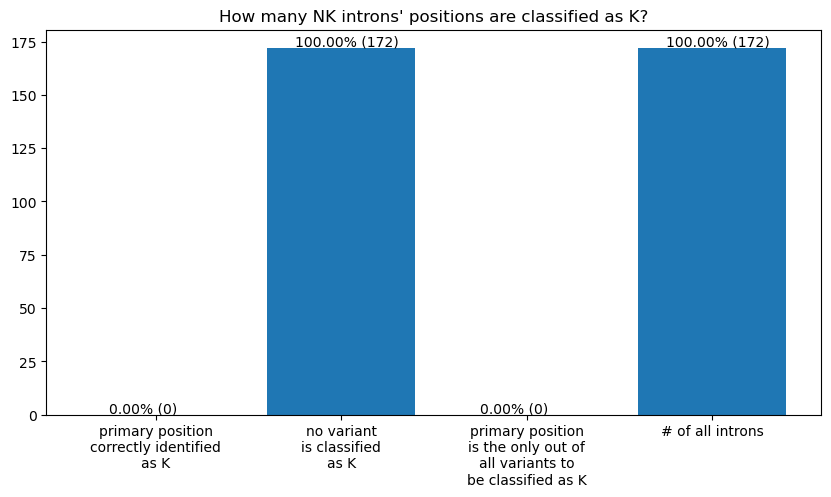

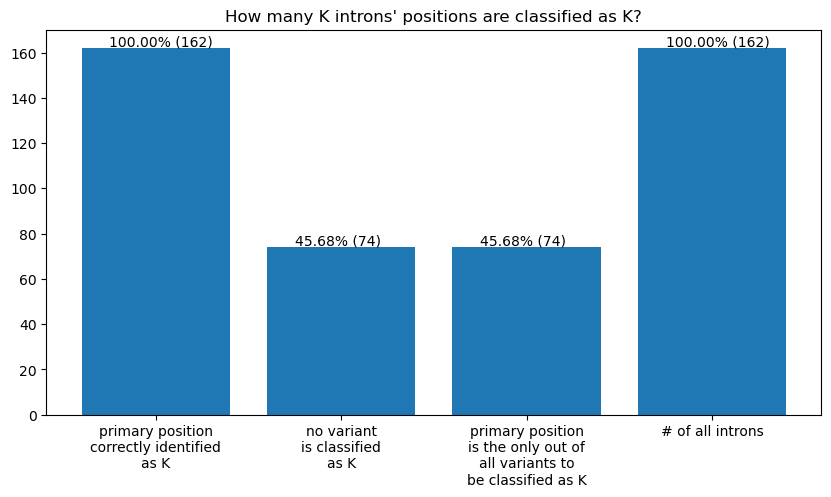

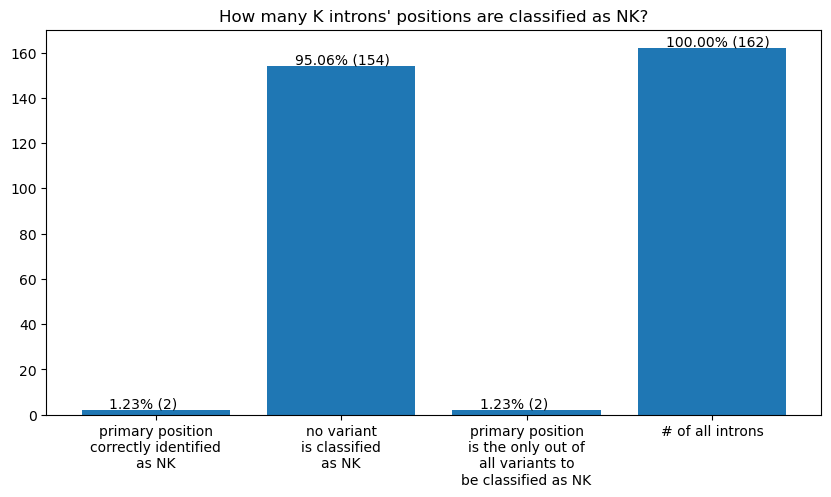

In [12]:
plot_correct_positions(introns_validation_set, grade_which="NK", grade_as="NK")
plot_correct_positions(introns_validation_set, grade_which="NK", grade_as="K")
plot_correct_positions(introns_validation_set, grade_which="K", grade_as="K")
plot_correct_positions(introns_validation_set, grade_which="K", grade_as="NK")